In [223]:
import pathlib
import jupedsim as jps
import pedpy
from numpy.random import normal  # normal distribution of free movement speed
from shapely import Polygon, GeometryCollection
import random

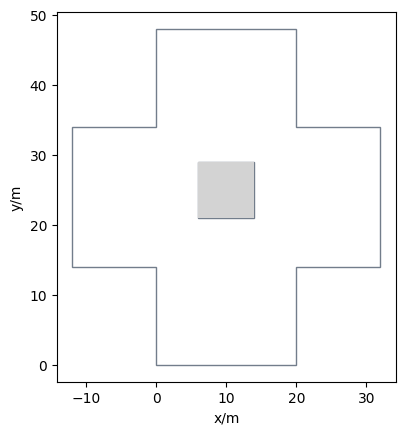

In [224]:
wings_length = 14
base_length = 20


north_landing = Polygon([(0, wings_length+base_length), (20, wings_length+base_length), (20, wings_length*2+base_length), (0, wings_length*2+base_length)])
main_landing = Polygon([(-12, wings_length), (32, wings_length), (32, wings_length+base_length), (-12, wings_length+base_length)])
south_landing = Polygon([(0, 0), (20, 0), (20, wings_length), (0, wings_length)])

center_booth = Polygon([(6, 21), (14, 21), (14, 29), (6, 29)])


area = GeometryCollection(north_landing.union(main_landing).union(south_landing).difference(center_booth))
walkable_area = pedpy.WalkableArea(area)
pedpy.plot_walkable_area(walkable_area=walkable_area).set_aspect("equal")

In [ ]:
pos_in_spawning_area = []
num_agents = 15

def spawn_in_area(area : Polygon):
    pos_in_spawning_area.extend(
        jps.distributions.distribute_by_number(
            polygon=area,
            number_of_agents=num_agents,
            distance_to_agents=0.4,
            distance_to_polygon=0.2,
            seed=None,
        )
    )

south_left_entrance = Polygon([(0, 0), (3, 0), (3, 10), (0, 10)])
south_right_entrance = Polygon([(17, 0), (20, 0), (20, 10), (17, 10)])
north_left_entrance = Polygon([(0, 38), (3, 38), (3, 48), (0, 48)])
north_right_entrance = Polygon([(17, 38), (20, 38), (20, 48), (17, 48)])

spawn_in_area(south_left_entrance)
spawn_in_area(south_right_entrance)
spawn_in_area(north_left_entrance)
spawn_in_area(north_right_entrance)

right_exit = Polygon([(30, 14), (32, 14), (32, 34), (30, 34)])
left_exit = Polygon([(-12, 14), (-10, 14), (-10, 34), (-12, 34)])
exit_areas = [right_exit, left_exit]

In [226]:
def plot_simulation_configuration(
    walkable_area, spawning_area, starting_positions, exit_area
):
    axes = pedpy.plot_walkable_area(walkable_area=walkable_area)
    axes.fill(*spawning_area.exterior.xy, color="lightgrey")
    axes.fill(*exit_area.exterior.xy, color="indianred")
    axes.scatter(*zip(*starting_positions))
    axes.set_xlabel("x/m")
    axes.set_ylabel("y/m")
    axes.set_aspect("equal")

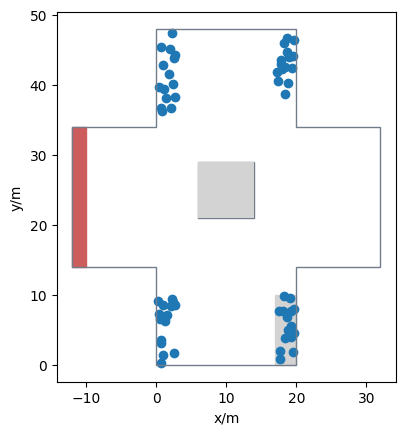

In [227]:
plot_simulation_configuration(
    walkable_area, south_right_entrance, pos_in_spawning_area, left_exit
)

In [228]:
trajectory_file = "corner.sqlite"  # output file
simulation = jps.Simulation(
    model=jps.AnticipationVelocityModel(),
    geometry=area,
    trajectory_writer=jps.SqliteTrajectoryWriter(
        output_file=pathlib.Path(trajectory_file)
    ),
)

In [229]:
exit_ids = []
for exit_area in exit_areas:
    exit_ids.append(simulation.add_exit_stage(exit_area.exterior.coords[:-1]))

journeys = []
for exit_id in exit_ids:
    journeys.append(jps.JourneyDescription([exit_id]))

journey_ids = []
for journey in journeys:
    journey_ids.append(simulation.add_journey(journey))

In [230]:
v_distribution = normal(1.34, 0.05, num_agents * 4)

i = 0
for pos, v0 in zip(pos_in_spawning_area, v_distribution):
    random_index = random.randrange(len(journey_ids))
    simulation.add_agent(
        jps.AnticipationVelocityModelAgentParameters(
            journey_id=journey_ids[random_index],
            stage_id=exit_ids[random_index],
            position=pos,
            desired_speed=v0,
            time_gap=random.uniform(0.0, 5.0)
        )
    )

while simulation.agent_count() > 0:
    simulation.iterate()

In [231]:
from jupedsim.internal.notebook_utils import animate, read_sqlite_file

trajectory_data, walkable_area = read_sqlite_file(trajectory_file)
animate(trajectory_data, walkable_area, every_nth_frame=10)